# DDoS Auswertung

## 0. Foreplay

### Notes:

instead of polars, the polars-lts-cpu package is used, to run on the old CPU's of the mobi8

### Imports

In [4]:
from pathlib import Path
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import pyarrow.parquet as pq
import gc

### Global parameters

In [16]:
SERVER_IP = "141.22.28.227"
PARQUET_FILE = "data/interim/ddos_1/batch_1_1000.parquet"
PARQUET_FOLDER = "data/processed/ddos_1/batch_1_1000/"
PLOT_FOLDER = "plots/batch_1_1000/"

### external IANA protocol list to convert numbers to names

In [6]:
# read IANA list to convert number to text
lf_pro_nb = (
    pl.scan_csv("data/external/protocol-numbers-1.csv", ignore_errors=True)
      .select("Decimal", "Keyword")
).rename({"Keyword": "ip.proto.name", "Decimal": "ip.proto.num"})
lf_pro_nb.head(10).collect()

ip.proto.num,ip.proto.name
i64,str
0,"""HOPOPT"""
1,"""ICMP"""
2,"""IGMP"""
3,"""GGP"""
4,"""IPv4"""
5,"""ST"""
6,"""TCP"""
7,"""CBT"""
8,"""EGP"""


In [7]:
# lf = (
#     lf.join(lf_pro_nb, left_on="ip.proto", right_on="ip.proto.num", how="left")
#     .rename({"ip.proto": "ip.proto.num"})
#     .pipe(lambda lf: lf.select(
#     (cols := lf.collect_schema().names(), cols.insert(5, cols.pop(cols.index("ip.proto.name"))), cols)[-1]
# ))
# )

# lf.head(10).collect()

### Read

In [8]:
lf = pl.scan_parquet(PARQUET_FILE).drop("dtls.record.content_type", "dtls.record.version", "dtls.handshake.type")

## 1. General Analysis

### Overview

In [9]:
total_packets = lf.select(pl.len()).collect().item()
total_bytes = lf.select(pl.col("frame.len").sum()).collect().item()

t_start = lf.select(pl.col("frame.datetime").min()).collect().item()
t_end = lf.select(pl.col("frame.datetime").max()).collect().item()
if t_start and t_end != None:
    duration_s = (t_end - t_start).total_seconds()

avg_len = (
    lf.select(pl.col("frame.len").mean())
    .collect()
    .item()
)
max_len = (
    lf.select(pl.col("frame.len").max())
    .collect()
    .item()
)

print(f"All pakets          : {total_packets:>12,}")
print(f"All bytes           : {total_bytes:>12,}  ({total_bytes/1e6:.1f} MB)")
print(f"Timepoints          : {t_start}  →  {t_end}")
print(f"Duration            : {duration_s:.1f}s / {duration_s/60:.1f}min / {duration_s/60/60:.1f}hours")
print(f"Ø Packetrate        : {total_packets/duration_s:>10,.1f} pkt/s")
print(f"Ø Bitrate           : {total_bytes*8/duration_s/1e6:>10,.1f} Mbit/s")
print(f"Average packet size : {avg_len:.1f} bytes")
print(f"Maximum packet size : {max_len} bytes")

All pakets          :  696,340,178
All bytes           : 801,727,874,184  (801727.9 MB)
Timepoints          : 2025-08-13 15:51:49.573544  →  2025-08-13 17:46:30.464776
Duration            : 6880.9s / 114.7min / 1.9hours
Ø Packetrate        :  101,199.1 pkt/s
Ø Bitrate           :      932.1 Mbit/s
Average packet size : 1151.3 bytes
Maximum packet size : 18890 bytes


### Sample

In [10]:
df_sample = lf.limit(1000).collect().sample(10)
df_sample
del df_sample

In [11]:
double_ip = lf.filter(
    pl.col("ip.ttl").str.contains(",") | pl.col("ip.proto").str.contains(",")
).collect()
print(double_ip.shape)
double_ip
del double_ip

(6821217, 32)


### IPv6

In [12]:
df_ipv6 = lf.filter(
    pl.col("ipv6.src").is_not_null() | pl.col("ipv6.dst").is_not_null()
).collect()

df_ipv6.write_parquet(PARQUET_FOLDER + "only_ipv6.parquet", compression="zstd")
print(df_ipv6)
del df_ipv6

shape: (4_004, 32)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ frame.dat ┆ frame.len ┆ frame.pro ┆ ip.src    ┆ … ┆ coap.resp ┆ coap.resp ┆ coap.payl ┆ source_f │
│ etime     ┆ ---       ┆ tocols    ┆ ---       ┆   ┆ onse_to   ┆ onse_in   ┆ oad_lengt ┆ ile      │
│ ---       ┆ i64       ┆ ---       ┆ str       ┆   ┆ ---       ┆ ---       ┆ h         ┆ ---      │
│ datetime[ ┆           ┆ str       ┆           ┆   ┆ str       ┆ str       ┆ ---       ┆ str      │
│ μs]       ┆           ┆           ┆           ┆   ┆           ┆           ┆ str       ┆          │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ 2025-08-1 ┆ 1374      ┆ eth:ether ┆ 106.8.207 ┆ … ┆ null      ┆ null      ┆ null      ┆ data/raw │
│ 3 15:51:5 ┆           ┆ type:ip:u ┆ .199      ┆   ┆           ┆           ┆           ┆ /ddos_1/ │
│ 1.835864  ┆           ┆ dp:teredo ┆           ┆   ┆           ┆       

#### Incoming vs. Outgoing

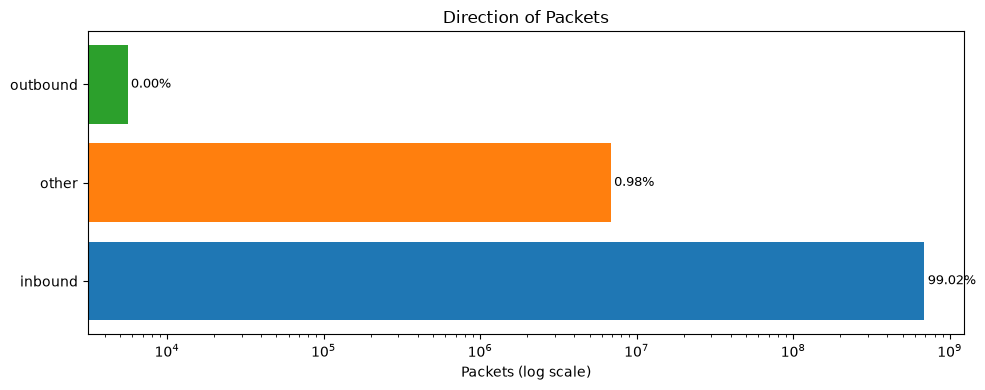

In [13]:
df_by_direction = (
    lf.with_columns(
        pl.coalesce(["ip.src", "ipv6.src"]).alias("src"),
        pl.coalesce(["ip.dst", "ipv6.dst"]).alias("dst"),
    )
    .with_columns(
        pl.when(pl.col("src") == SERVER_IP)
        .then(pl.lit("outbound"))  # Server -> Client (Response)
        .when(pl.col("dst") == SERVER_IP)
        .then(pl.lit("inbound"))  # Client -> Server (Request)
        .otherwise(pl.lit("other"))
        .alias("direction")
    )
    .group_by("direction")
    .agg(pl.len().alias("count"))
    .collect()
    .sort("count", descending=True)
)
df_by_direction.write_parquet(PARQUET_FOLDER + "by_direction.parquet", compression="zstd")

total = df_by_direction["count"].sum()

labels = df_by_direction["direction"].to_list()
counts = df_by_direction["count"].to_list()

percentages = [c / total * 100 for c in counts]
colors = cm.tab10.colors[: len(labels)]

fig, ax = plt.subplots(figsize=(10, 4))

y_pos = range(len(labels))
ax.barh(y_pos, counts, color=colors)

for i, (count, pct) in enumerate(zip(counts, percentages)):
    ax.text(count * 1.05, i, f"{pct:.2f}%", va="center", fontsize=9)

ax.set_yticks(y_pos)
ax.set_yticklabels(labels)
ax.set_xscale("log")
ax.set_xlabel("Packets (log scale)")
ax.set_title("Direction of Packets")

plt.tight_layout()
plt.savefig(PLOT_FOLDER + "packets_direction")
plt.show()

plt.close(fig)
del df_by_direction

#### By Transport Protocol

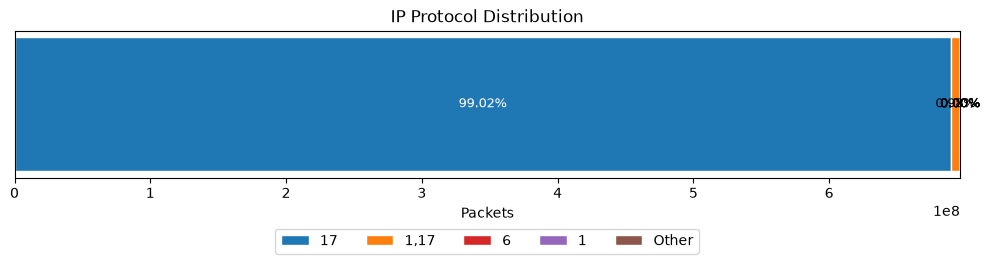

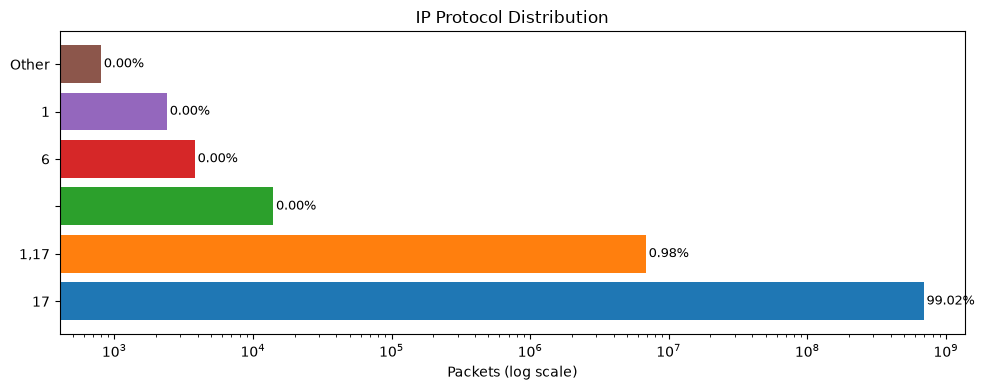

In [ ]:
TOP_N = 5

df_by_proto = (
    lf.group_by("ip.proto")
    .agg(pl.len().alias("count"))
    .collect()
    .sort("count", descending=True)
)
df_by_proto.write_parquet(PARQUET_FOLDER + "by_ip_proto", compression="zstd")

total = df_by_proto["count"].sum()
top = df_by_proto.head(TOP_N)
other = df_by_proto.tail(len(df_by_proto) - TOP_N)
other_count = other["count"].sum() if len(other) > 0 else 0

labels = top["ip.proto"].to_list()
counts = top["count"].to_list()

if other_count > 0:
    labels.append("Other")
    counts.append(other_count)

percentages = [c / total * 100 for c in counts]
colors = cm.tab10.colors[: len(labels)]

fig, ax = plt.subplots(figsize=(10, 4))

y_pos = range(len(labels))
ax.barh(y_pos, counts, color=colors)

for i, (count, pct) in enumerate(zip(counts, percentages)):
    ax.text(count * 1.05, i, f"{pct:.2f}%", va="center", fontsize=9)

ax.set_yticks(y_pos)
ax.set_yticklabels(labels)
ax.set_xscale("log")
ax.set_xlabel("Packets (log scale)")
ax.set_title("IP Protocol Distribution")

plt.tight_layout()
plt.savefig("plots/ip_proto_distr")
plt.show()

plt.close(fig)
del df_by_proto

#### Top-Talker (meiste Pakete / meiste Bytes)

In [15]:
df_by_ip_src = (
    lf.group_by("ip.src")
    .agg([
        pl.len().alias("packets"),
        pl.col("frame.len").sum().alias("bytes"),
    ])
    .sort("bytes", descending=True)
    .head(20)
    .collect()
)

labels = df_by_ip_src["ip.src"].to_list()
bytes_vals = df_by_ip_src["bytes"].to_list()
packets_vals = df_by_ip_src["packets"].to_list()

colors = cm.tab20.colors[: len(labels)]

fig, ax = plt.subplots(figsize=(10, 8))

y_pos = range(len(labels))
ax.barh(y_pos, bytes_vals, color=colors)

for i, (b, p) in enumerate(zip(bytes_vals, packets_vals)):
    ax.text(b * 1.01, i, f"{b:,} B / {p:,} pkts", va="center", fontsize=8)

ax.set_yticks(y_pos)
ax.set_yticklabels(labels)
ax.invert_yaxis()
ax.set_xlabel("Bytes")
ax.set_title("Top 20 Source IPs by Bytes")

plt.tight_layout()
plt.savefig("top20_ip_src.png", dpi=150, bbox_inches="tight")
plt.close(fig)

del df_by_ip_src, labels, bytes_vals, packets_vals
gc.collect()

KeyboardInterrupt: 

In [ ]:
lf_ipv6 = lf.filter(
    pl.col("ipv6.src").is_not_null() | pl.col("ipv6.dst").is_not_null()
).collect()
lf_ipv6

frame.datetime,frame.len,frame.protocols,ip.src,ip.dst,ip.proto,ip.ttl,ipv6.src,ipv6.dst,ipv6.hlim,udp.srcport,udp.dstport,udp.length,tcp.srcport,tcp.dstport,tcp.len,coap.version,coap.type,coap.code,coap.mid,coap.token,coap.token_len,coap.opt.uri_path,coap.opt.uri_query,coap.opt.block_number,coap.opt.block_mflag,coap.opt.block_size,coap.opt.observe,coap.response_to,coap.response_in,coap.payload_length,source_file
datetime[μs],i64,str,str,str,str,str,str,str,str,str,str,i64,str,str,i64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str
2025-08-13 15:51:51.835864,1374,"""eth:ethertype:ip:udp:teredo:ip…","""106.8.207.199""","""141.22.28.227""","""17""","""51""","""2f3e:3b74:6974:6c65:3d22:4765:…","""6c20:496e:666f:223b:6374:3d30:…","""60""","""5683""","""3544""",1340,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""data/raw/ddos_1/13082025_DDOS_…"
2025-08-13 15:51:52.796131,191,"""eth:ethertype:vlan:ethertype:i…",null,null,null,null,"""fe80::21a:e8ff:fe92:6664""","""ff02::1:2""","""1""","""546""","""547""",133,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""data/raw/ddos_1/13082025_DDOS_…"
2025-08-13 15:51:57.292536,191,"""eth:ethertype:vlan:ethertype:i…",null,null,null,null,"""fe80::21a:e8ff:fe99:e4cc""","""ff02::1:2""","""1""","""546""","""547""",133,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""data/raw/ddos_1/13082025_DDOS_…"
2025-08-13 15:51:57.478403,162,"""eth:ethertype:ip:udp:amt:ip:ip…","""181.199.119.134""","""141.22.28.227""","""17""","""118""","""3b49:6e73:7461:6e63:654e:616d:…","""5351:4c53:4552:5645:523b:4973:…","""82""","""1434""","""2268""",128,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""data/raw/ddos_1/13082025_DDOS_…"
2025-08-13 15:51:58.479987,191,"""eth:ethertype:vlan:ethertype:i…",null,null,null,null,"""fe80::21a:e8ff:fe97:c8f7""","""ff02::1:2""","""1""","""546""","""547""",133,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""data/raw/ddos_1/13082025_DDOS_…"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2025-08-13 17:46:26.323593,191,"""eth:ethertype:vlan:ethertype:i…",null,null,null,null,"""fe80::21a:e8ff:fe96:ee87""","""ff02::1:2""","""1""","""546""","""547""",133,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""data/raw/ddos_1/13082025_DDOS_…"
2025-08-13 17:46:27.700537,165,"""eth:ethertype:vlan:ethertype:i…",null,null,null,null,"""fe80::21a:e8ff:fe96:2755""","""ff02::1:2""","""1""","""546""","""547""",107,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""data/raw/ddos_1/13082025_DDOS_…"
2025-08-13 17:46:28.782771,191,"""eth:ethertype:vlan:ethertype:i…",null,null,null,null,"""fe80::21a:e8ff:fe96:c58c""","""ff02::1:2""","""1""","""546""","""547""",133,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""data/raw/ddos_1/13082025_DDOS_…"


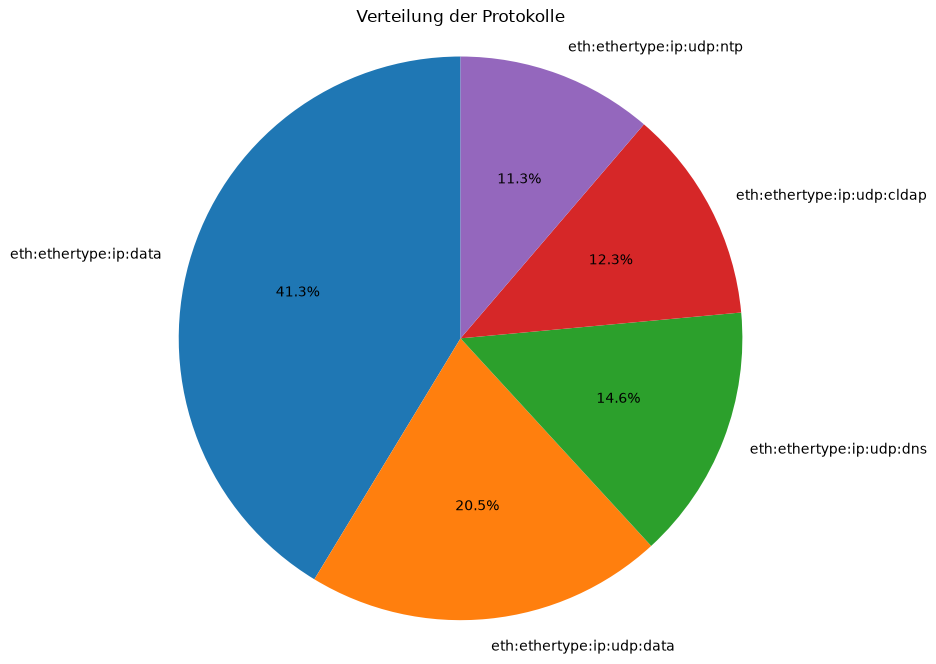

In [ ]:
protocol_counts = (
    lf.group_by("frame.protocols")
      .len()
      .sort("len", descending=True)
      .head(5)
      .collect()
)

plt.figure(figsize=(8, 8))
plt.pie(
    protocol_counts["len"],
    labels=protocol_counts["frame.protocols"].to_list(),
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Verteilung der Protokolle")
plt.axis("equal")  # Kreis statt Ellipse
plt.show()